# **PRCP-1012: PUBG Game Winner Prediction**
---
**Project ID:** PRCP-1012  
**Type:** Regression — Predicting Win Placement Percentage  
**Target Variable:** `winPlacePerc` (0.0 = last place → 1.0 = winner)  
**Best Model:** To be determined after comparison  
**Dataset:** ~4.4 million rows | 29 features

## **Problem Statement**

### Task 1: Prepare a complete data analysis report on the given data.

PUBG (PlayerUnknown's Battlegrounds) is a battle royale game where players compete to be the last one standing. Understanding what factors contribute to winning can help players improve their strategy.

### Task 2: Create a predictive model

Predict the **win probability (winPlacePerc)** of a PUBG match and identify the most important factors affecting win probability.

- `winPlacePerc = 1.0` → Winner (1st place)  
- `winPlacePerc = 0.0` → Last place  
- All values between 0 and 1 represent relative finishing position

## **Dataset Description**

| Feature | Description |
|---------|-------------|
| Id | Unique player ID |
| groupId | Group/team the player belongs to |
| matchId | Unique match ID |
| assists | Number of assists (helped kill) |
| boosts | Boost items used (energy drinks, painkillers) |
| damageDealt | Total damage dealt to other players |
| DBNOs | Number of players knocked down |
| headshotKills | Kills by headshot |
| heals | Healing items used |
| killPlace | Ranking by kills in match |
| killPoints | Kill-based rating |
| kills | Number of kills |
| killStreaks | Max kills in short time |
| longestKill | Longest kill distance (meters) |
| matchDuration | Duration of match in seconds |
| matchType | Solo / Duo / Squad |
| maxPlace | Worst placement in match |
| numGroups | Number of groups in match |
| rankPoints | Elo-like ranking |
| revives | Times revived teammates |
| rideDistance | Distance traveled by vehicle |
| roadKills | Kills from vehicle |
| swimDistance | Distance swum |
| teamKills | Times killed own teammate |
| vehicleDestroys | Vehicles destroyed |
| walkDistance | Distance walked |
| weaponsAcquired | Number of weapons picked up |
| winPoints | Win-based rating |
| **winPlacePerc** | **TARGET: Win placement percentage** |

## **Task 1: Data Analysis Report**
### **Step 1: Install Required Libraries**

In [14]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### **Step 2: Import Libraries**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    xgb_available = True
    print('✅ XGBoost available')
except:
    xgb_available = False
    print('⚠️ XGBoost not available — will skip')

try:
    from lightgbm import LGBMRegressor
    lgbm_available = True
    print('✅ LightGBM available')
except:
    lgbm_available = False
    print('⚠️ LightGBM not available — will skip')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print('✅ All libraries imported!')
print(f'✅ Pandas version : {pd.__version__}')
print(f'✅ NumPy version  : {np.__version__}')

⚠️ XGBoost not available — will skip
⚠️ LightGBM not available — will skip
✅ All libraries imported!
✅ Pandas version : 2.3.3
✅ NumPy version  : 2.3.5


### **Step 3: Load Dataset**

We load the dataset and immediately sample 200,000 rows for efficient processing.  
The full dataset has ~4.4 million rows — sampling 200K is statistically representative and trains much faster.

In [16]:
# Load dataset
# Make sure pubg.csv is in the same folder as this notebook
import os

print("📁 Current folder:", os.getcwd())

# Load dataset
print("📂 Loading dataset...")
df_full = pd.read_csv("/Users/UWAIS/Desktop/GameWinnerProject/Data/pubg.csv")

print(f'✅ Full dataset shape   : {df_full.shape}')
print(f'✅ Full dataset size    : {df_full.memory_usage(deep=True).sum() / 1e6:.1f} MB')

'''
# Sample 200,000 rows for efficient processing
SAMPLE_SIZE = 200000
df = df_full.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
'''

df = df_full.copy()

print("Memory usage BEFORE optimization:")
df.info(memory_usage='deep')

print(f'✅ Using full dataset shape: {df.shape}')
print(f'✅ Dataset size: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\n--- First 5 rows ---')
df.head()

'''
print(f'\n✅ Sampled dataset shape: {df.shape}')
print(f'✅ Sampled dataset size  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\n--- First 5 rows ---')
df.head()
'''

📁 Current folder: /Users/UWAIS/GameWinnerProject/notebooks
📂 Loading dataset...
✅ Full dataset shape   : (4446966, 29)
✅ Full dataset size    : 2122.4 MB
Memory usage BEFORE optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  road

"\nprint(f'\n✅ Sampled dataset shape: {df.shape}')\nprint(f'✅ Sampled dataset size  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')\nprint(f'\n--- First 5 rows ---')\ndf.head()\n"

### **Step 4: Basic Dataset Overview**

In [17]:
print('=== Dataset Info ===')
print(f'Shape         : {df.shape}')
print(f'Rows          : {df.shape[0]:,}')
print(f'Columns       : {df.shape[1]}')
print()

print('=== Column Data Types ===')
print(df.dtypes)
print()

print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df[missing_df['Missing Count'] > 0].empty:
    print('✅ No missing values found!')

=== Dataset Info ===
Shape         : (4446966, 29)
Rows          : 4,446,966
Columns       : 29

=== Column Data Types ===
Id                  object
groupId             object
matchId             object
assists              int64
boosts               int64
damageDealt        float64
DBNOs                int64
headshotKills        int64
heals                int64
killPlace            int64
killPoints           int64
kills                int64
killStreaks          int64
longestKill        float64
matchDuration        int64
matchType           object
maxPlace             int64
numGroups            int64
rankPoints           int64
revives              int64
rideDistance       float64
roadKills            int64
swimDistance       float64
teamKills            int64
vehicleDestroys      int64
walkDistance       float64
weaponsAcquired      int64
winPoints            int64
winPlacePerc       float64
dtype: object

=== Missing Values ===
              Missing Count  Missing %
winPlacePerc     

### **Step 5: Statistical Summary**

In [18]:
print('=== Statistical Summary (Numerical Features) ===')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print(df.describe().T)

=== Statistical Summary (Numerical Features) ===
                      count     mean      std    min      25%      50%  \
assists         4446966.000    0.234    0.589  0.000    0.000    0.000   
boosts          4446966.000    1.107    1.716  0.000    0.000    0.000   
damageDealt     4446966.000  130.717  170.781  0.000    0.000   84.240   
DBNOs           4446966.000    0.658    1.146  0.000    0.000    0.000   
headshotKills   4446966.000    0.227    0.602  0.000    0.000    0.000   
heals           4446966.000    1.370    2.680  0.000    0.000    0.000   
killPlace       4446966.000   47.599   27.463  1.000   24.000   47.000   
killPoints      4446966.000  505.006  627.505  0.000    0.000    0.000   
kills           4446966.000    0.925    1.558  0.000    0.000    0.000   
killStreaks     4446966.000    0.544    0.711  0.000    0.000    0.000   
longestKill     4446966.000   22.998   50.973  0.000    0.000    0.000   
matchDuration   4446966.000 1579.506  258.740  9.000 1367.000 1

### **Step 6: Target Variable Analysis**

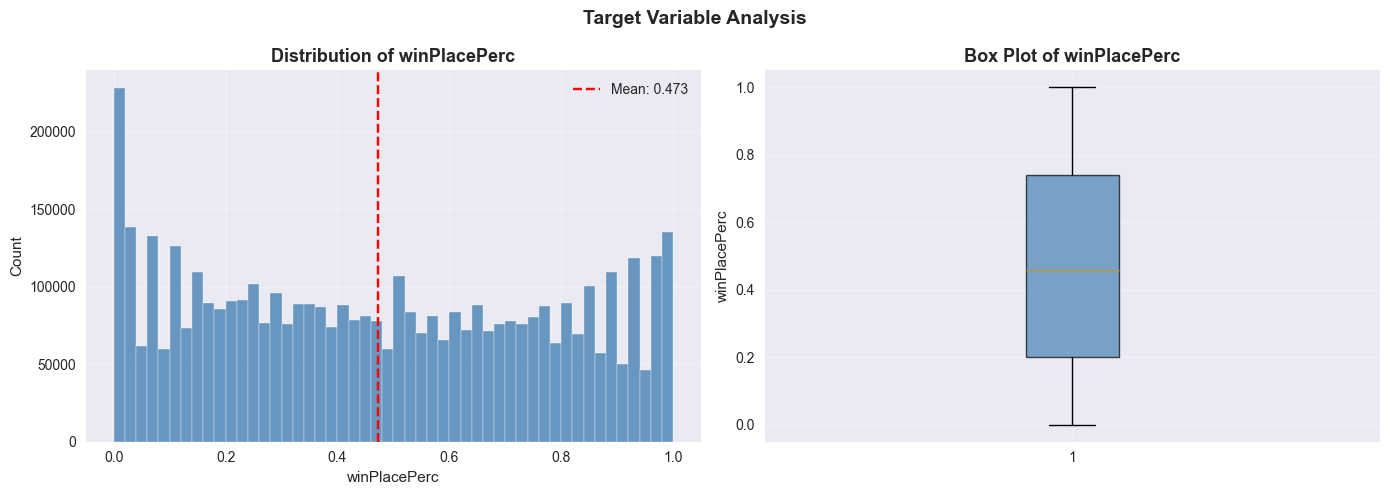

Mean   : 0.4728
Median : 0.4583
Std    : 0.3074
Min    : 0.0000
Max    : 1.0000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['winPlacePerc'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of winPlacePerc', fontsize=13, fontweight='bold')
axes[0].set_xlabel('winPlacePerc')
axes[0].set_ylabel('Count')
axes[0].axvline(df['winPlacePerc'].mean(), color='red', linestyle='--', label=f'Mean: {df["winPlacePerc"].mean():.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['winPlacePerc'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of winPlacePerc', fontsize=13, fontweight='bold')
axes[1].set_ylabel('winPlacePerc')
axes[1].grid(alpha=0.3)

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean   : {df["winPlacePerc"].mean():.4f}')
print(f'Median : {df["winPlacePerc"].median():.4f}')
print(f'Std    : {df["winPlacePerc"].std():.4f}')
print(f'Min    : {df["winPlacePerc"].min():.4f}')
print(f'Max    : {df["winPlacePerc"].max():.4f}')

### **Step 7: Match Type Analysis**

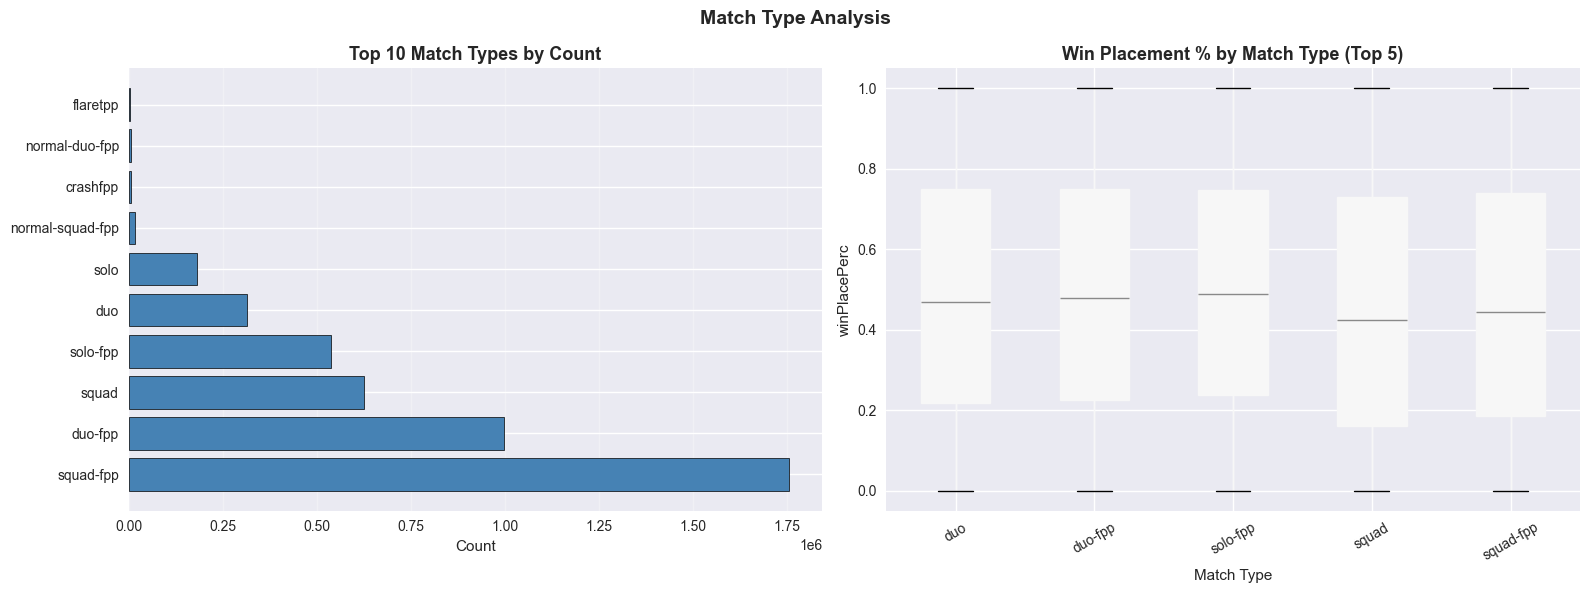

Match Type Distribution:
matchType
squad-fpp           1756186
duo-fpp              996691
squad                626526
solo-fpp             536762
duo                  313591
solo                 181943
normal-squad-fpp      17174
crashfpp               6287
normal-duo-fpp         5489
flaretpp               2505
normal-solo-fpp        1682
flarefpp                718
normal-squad            516
crashtpp                371
normal-solo             326
normal-duo              199
Name: count, dtype: int64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Match type counts
match_counts = df['matchType'].value_counts().head(10)
axes[0].barh(match_counts.index, match_counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 10 Match Types by Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# winPlacePerc by match type (top 5)
top5_types = df['matchType'].value_counts().head(5).index
df_top5 = df[df['matchType'].isin(top5_types)]
df_top5.boxplot(column='winPlacePerc', by='matchType', ax=axes[1],
                patch_artist=True)
axes[1].set_title('Win Placement % by Match Type (Top 5)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Match Type')
axes[1].set_ylabel('winPlacePerc')
plt.sca(axes[1])
plt.xticks(rotation=30)

plt.suptitle('Match Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matchtype_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Match Type Distribution:')
print(df['matchType'].value_counts())

**Report:** Squad matches are the most common match type. Win placement percentage distribution is similar across match types, suggesting that match type alone is not a strong predictor of winning.

### **Step 8: Kills & Combat Analysis**

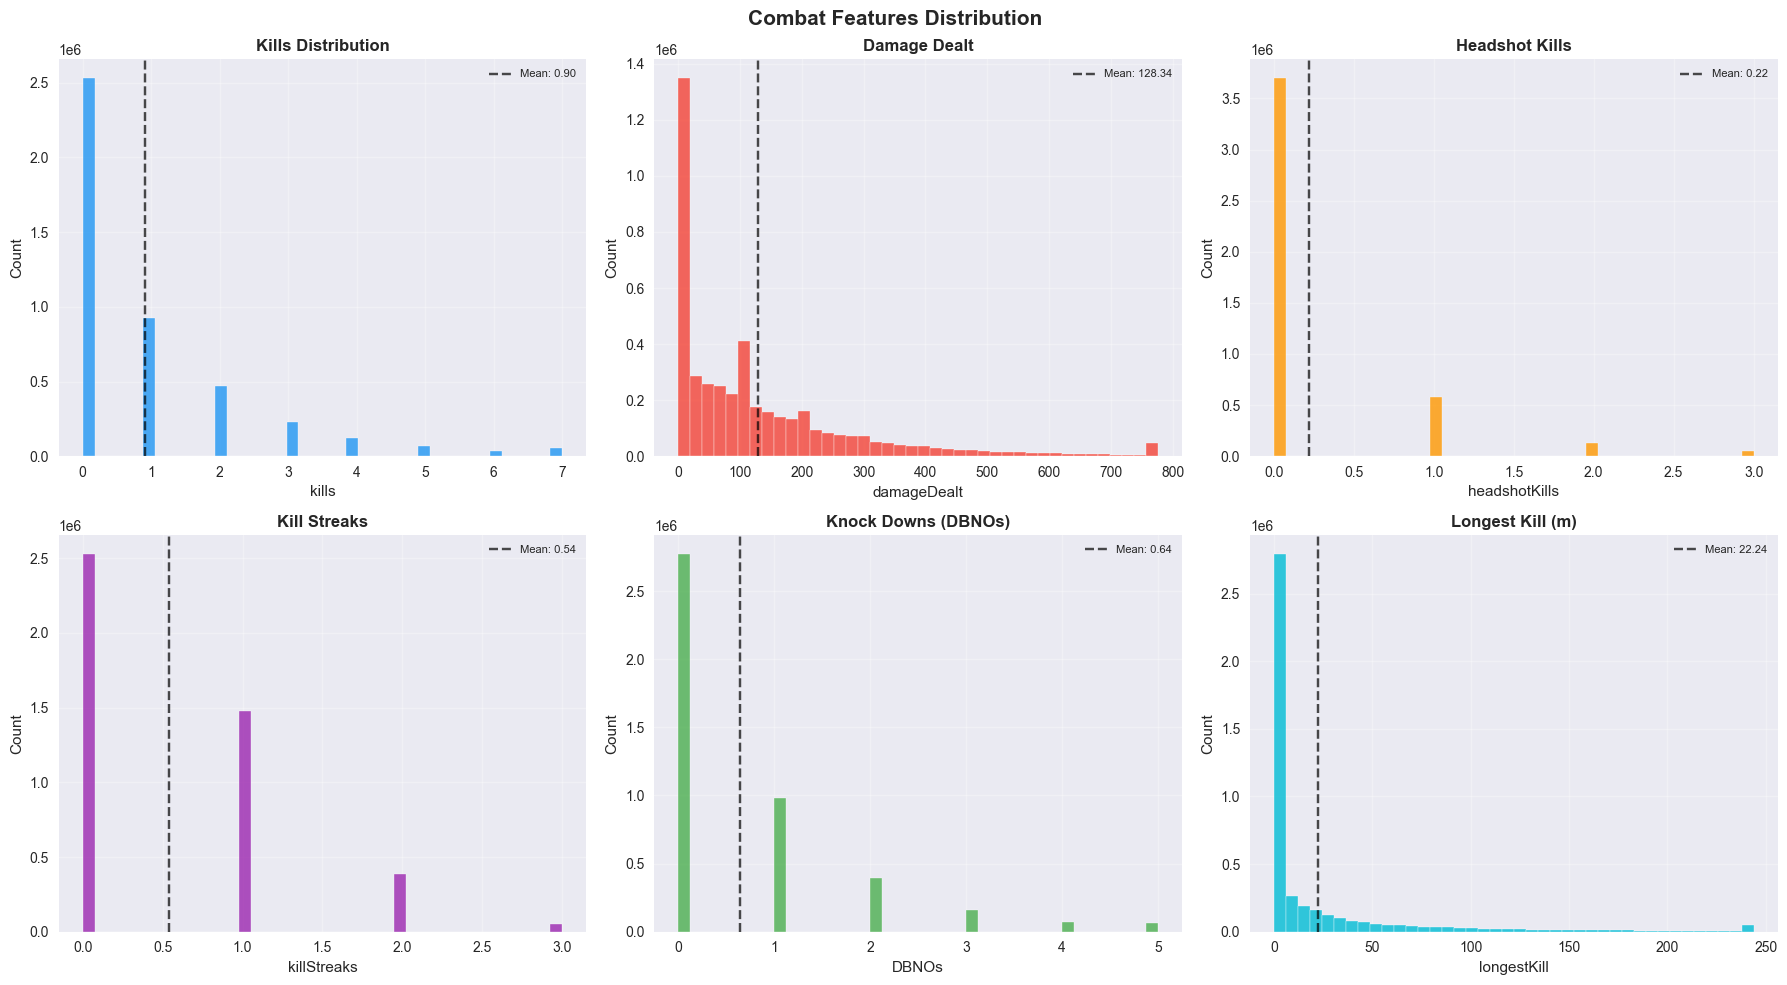

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

combat_features = ['kills', 'damageDealt', 'headshotKills', 'killStreaks', 'DBNOs', 'longestKill']
titles = ['Kills Distribution', 'Damage Dealt', 'Headshot Kills', 'Kill Streaks', 'Knock Downs (DBNOs)', 'Longest Kill (m)']
colors = ['#2196F3', '#F44336', '#FF9800', '#9C27B0', '#4CAF50', '#00BCD4']

for ax, feat, title, color in zip(axes.flatten(), combat_features, titles, colors):
    data = df[feat].clip(upper=df[feat].quantile(0.99))
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7,
               label=f'Mean: {data.mean():.2f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Combat Features Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('combat_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### **Step 9: Movement & Survival Analysis**

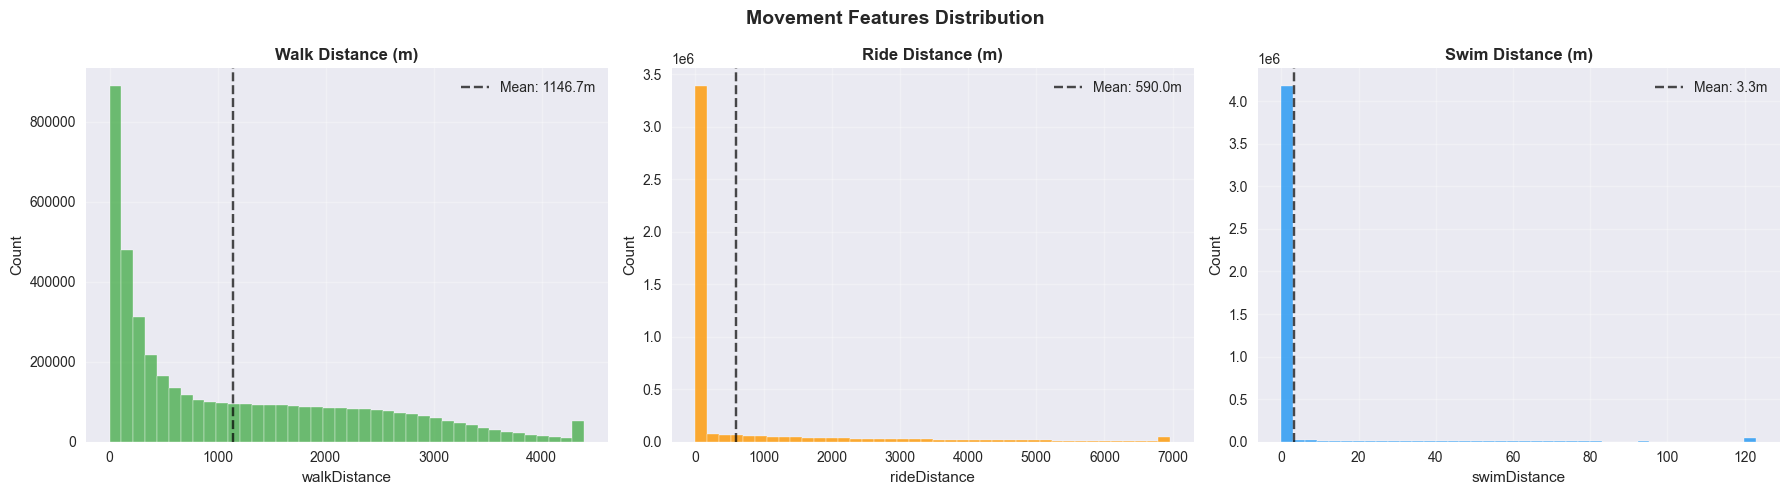

Correlation with winPlacePerc:
  walkDistance        : 0.8109
  rideDistance        : 0.3429
  swimDistance        : 0.1496


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

movement_features = ['walkDistance', 'rideDistance', 'swimDistance']
titles = ['Walk Distance (m)', 'Ride Distance (m)', 'Swim Distance (m)']
colors = ['#4CAF50', '#FF9800', '#2196F3']

for ax, feat, title, color in zip(axes, movement_features, titles, colors):
    data = df[feat].clip(upper=df[feat].quantile(0.99))
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7,
               label=f'Mean: {data.mean():.1f}m')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Movement Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('movement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation between movement and winning
print('Correlation with winPlacePerc:')
for feat in movement_features:
    corr = df[feat].corr(df['winPlacePerc'])
    print(f'  {feat:<20}: {corr:.4f}')

**Report:** Walk distance is the most significant movement feature — players who move more tend to survive longer and win more often. Swim distance is very rare. Ride distance shows many players never use vehicles.

### **Step 10: Healing & Survival Items Analysis**

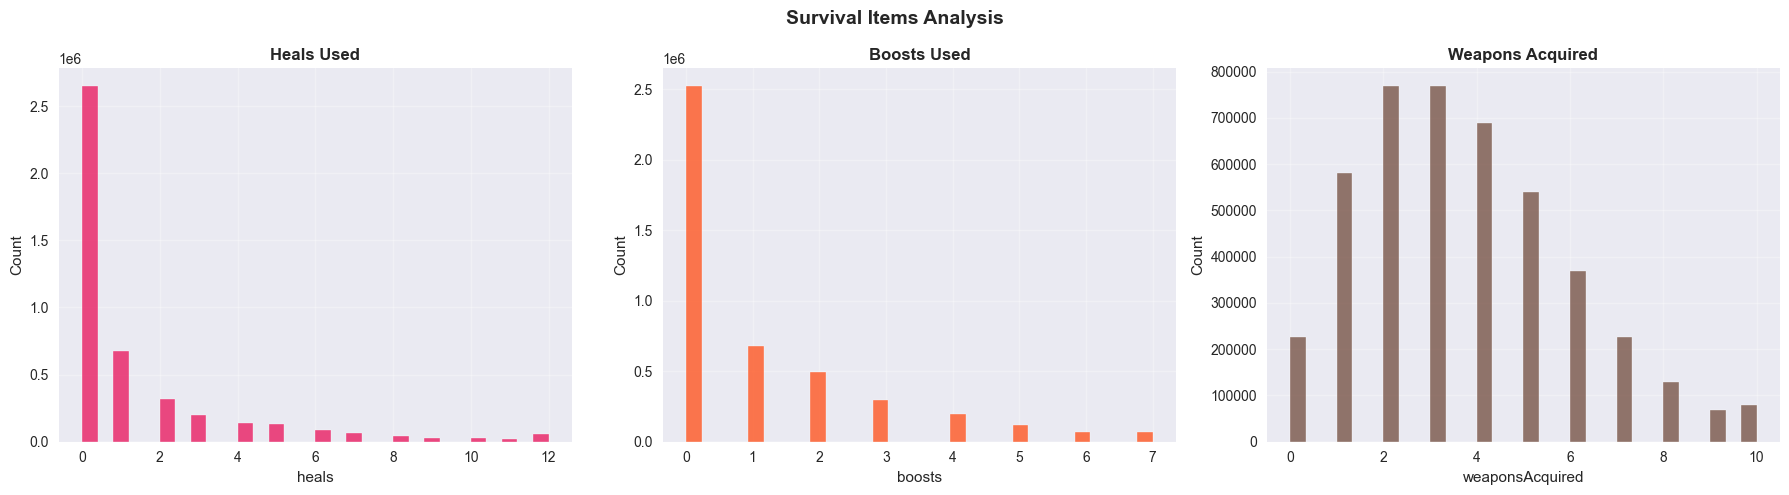

Correlation with winPlacePerc:
  heals               : 0.4279
  boosts              : 0.6342
  weaponsAcquired     : 0.5838


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

survival_features = ['heals', 'boosts', 'weaponsAcquired']
titles = ['Heals Used', 'Boosts Used', 'Weapons Acquired']
colors = ['#E91E63', '#FF5722', '#795548']

for ax, feat, title, color in zip(axes, survival_features, titles, colors):
    data = df[feat].clip(upper=df[feat].quantile(0.99))
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)

plt.suptitle('Survival Items Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with winPlacePerc:')
for feat in survival_features:
    corr = df[feat].corr(df['winPlacePerc'])
    print(f'  {feat:<20}: {corr:.4f}')

**Report:** Boosts have a notably high correlation with winning — players who use energy items survive longer in the end-game zone. Weapons acquired also correlates positively — looting more weapons means staying alive longer.

### **Step 11: Correlation Heatmap**

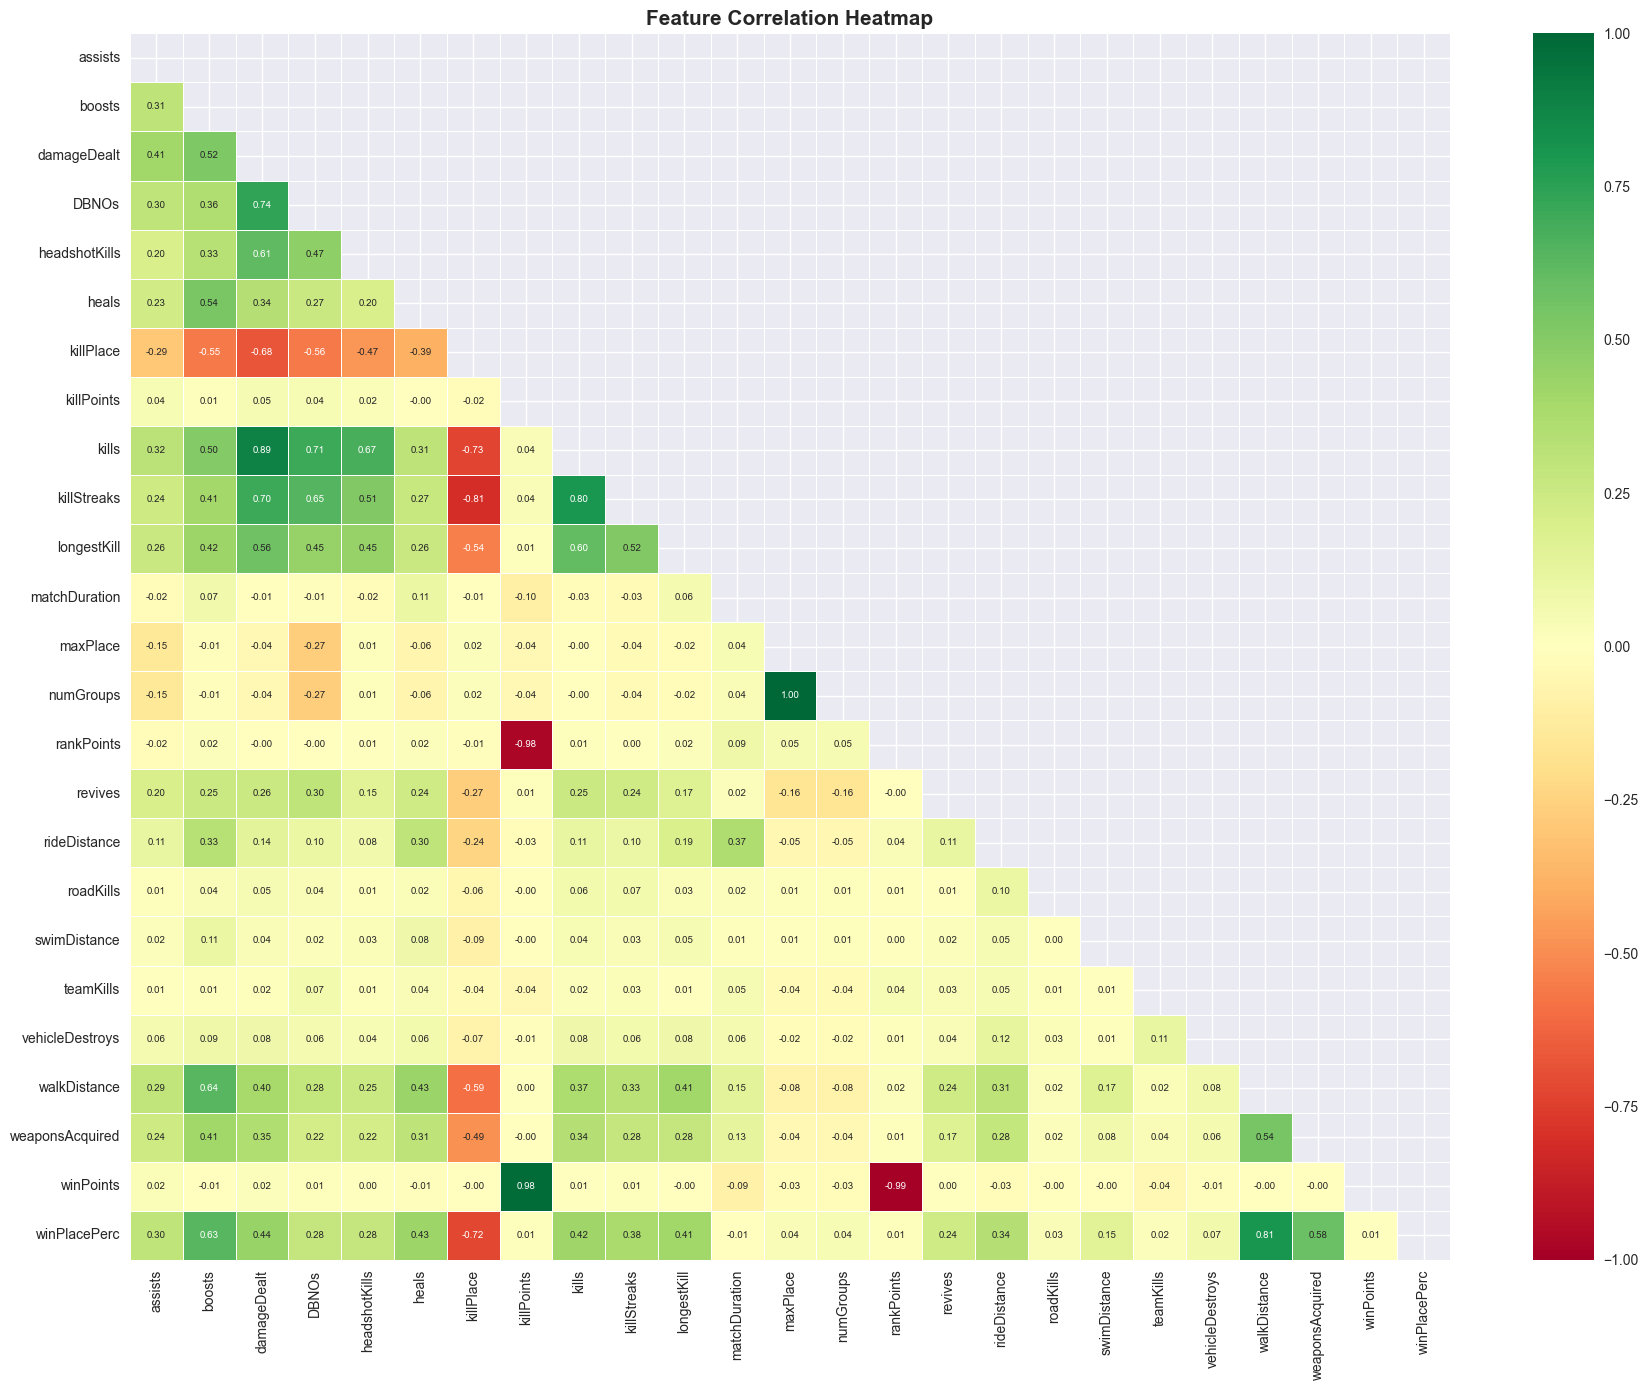

Top features correlated with winPlacePerc:
walkDistance       0.811
boosts             0.634
weaponsAcquired    0.584
damageDealt        0.441
heals              0.428
kills              0.420
longestKill        0.410
killStreaks        0.378
rideDistance       0.343
assists            0.299
DBNOs              0.280
headshotKills      0.278
revives            0.241
swimDistance       0.150
vehicleDestroys    0.073
numGroups          0.040
maxPlace           0.037
roadKills          0.035
teamKills          0.016
rankPoints         0.014
killPoints         0.013
winPoints          0.007
matchDuration     -0.005
killPlace         -0.719


In [24]:
# Select numerical columns for correlation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id', 'groupId', 'matchId']]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print('Top features correlated with winPlacePerc:')
target_corr = corr_matrix['winPlacePerc'].drop('winPlacePerc').sort_values(ascending=False)
print(target_corr.to_string())

**Report:** The correlation heatmap reveals that `walkDistance`, `boosts`, `weaponsAcquired`, and `kills` are positively correlated with winning. `killPlace` (lower kill rank = more kills) is negatively correlated. High correlation between some features suggests potential multicollinearity.

### **Step 12: Outlier Analysis**

=== Potential Cheater Detection ===
Players with kills > 30       : 102
Players with headshots > kills : 0
Players with 0 walkDistance   : 99,603
Players with damage=0, kills>0: 4,153



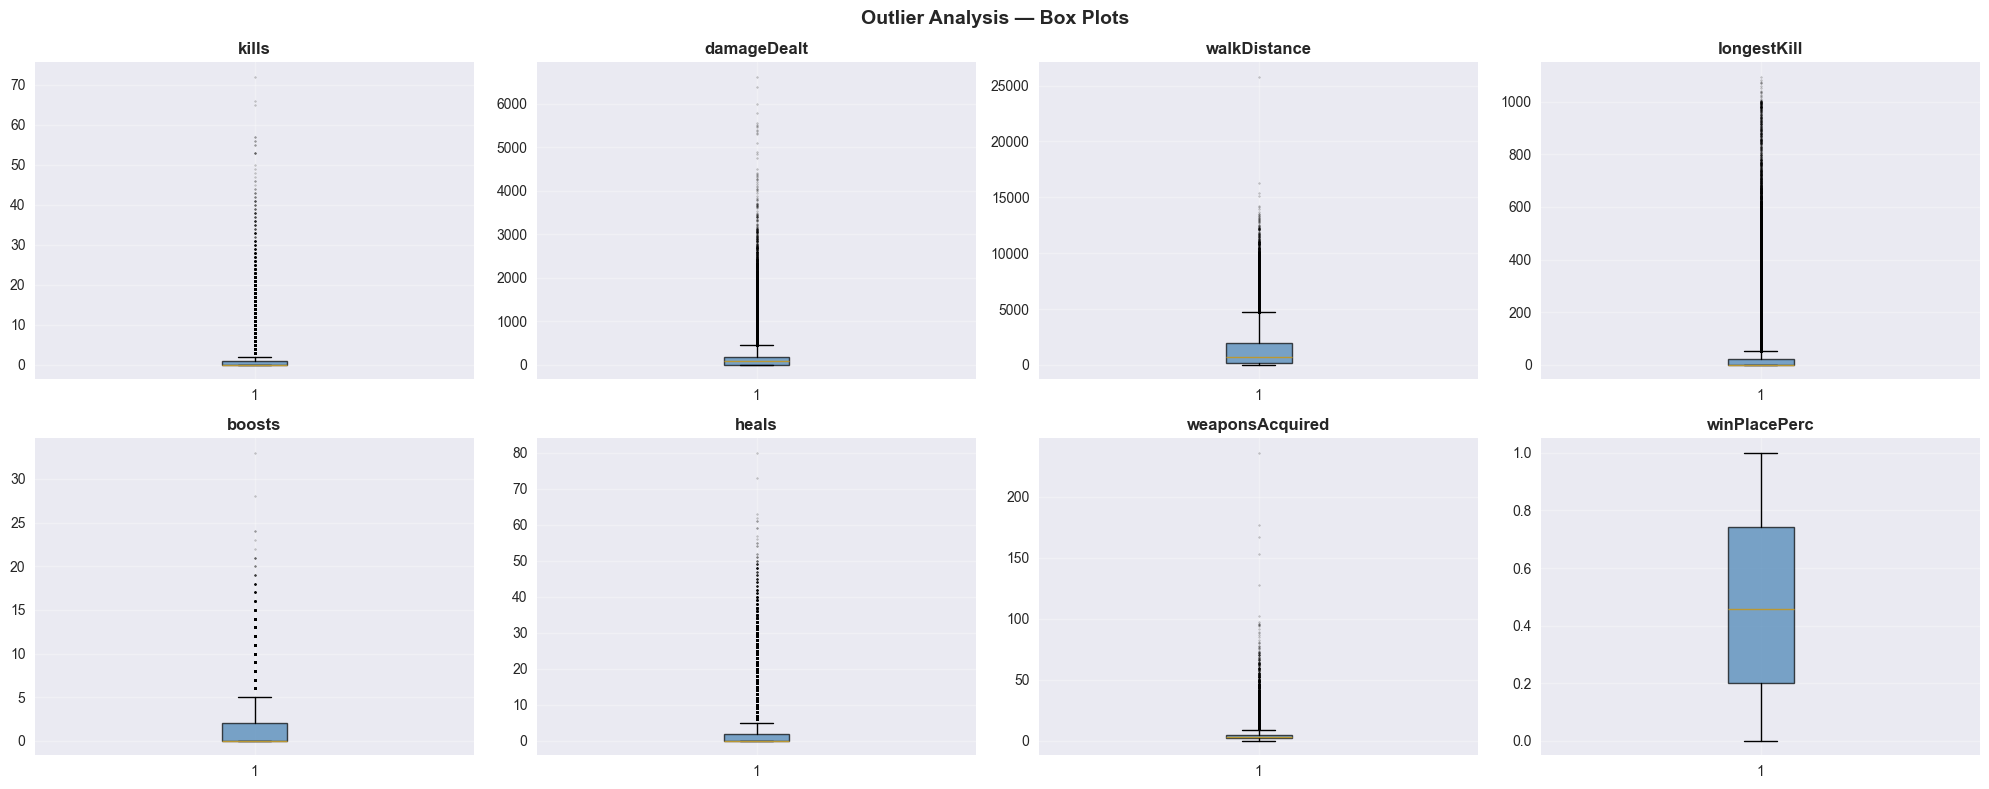

In [25]:
# Check for cheaters/anomalies
print('=== Potential Cheater Detection ===')
print(f'Players with kills > 30       : {(df["kills"] > 30).sum():,}')
print(f'Players with headshots > kills : {(df["headshotKills"] > df["kills"]).sum():,}')
print(f'Players with 0 walkDistance   : {(df["walkDistance"] == 0).sum():,}')
print(f'Players with damage=0, kills>0: {((df["damageDealt"] == 0) & (df["kills"] > 0)).sum():,}')
print()

# Box plots for key features
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
outlier_features = ['kills', 'damageDealt', 'walkDistance', 'longestKill',
                    'boosts', 'heals', 'weaponsAcquired', 'winPlacePerc']

for ax, feat in zip(axes.flatten(), outlier_features):
    ax.boxplot(df[feat].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
    ax.set_title(feat, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Outlier Analysis — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Report:** Outlier analysis reveals potential cheaters — players with 0 walk distance but kills, or damage dealt = 0 with kills > 0. These anomalies will be handled during preprocessing. Most numerical features have right-skewed distributions with extreme outliers.

---
## **Task 2: Build Predictive Models**
### **Step 13: Data Preprocessing**

In [26]:
print('=== Preprocessing ===')

# Work on a copy
df_model = df.copy()

# 1. Drop rows where target is null
df_model = df_model.dropna(subset=['winPlacePerc'])
print(f'After dropping null target: {df_model.shape}')

# 2. Drop ID columns (not useful for prediction)
drop_cols = ['Id', 'groupId', 'matchId']
df_model = df_model.drop(columns=drop_cols, errors='ignore')
print(f'After dropping ID cols: {df_model.shape}')

# 3. Remove cheater rows
# Players with kills but 0 damage = cheating
cheater_mask = (df_model['kills'] > 0) & (df_model['damageDealt'] == 0)
df_model = df_model[~cheater_mask]
print(f'After removing cheaters: {df_model.shape}')

# 4. Clip extreme outliers (99.5th percentile)
clip_features = ['kills', 'damageDealt', 'walkDistance', 'rideDistance',
                 'longestKill', 'heals', 'boosts', 'weaponsAcquired']
for feat in clip_features:
    upper = df_model[feat].quantile(0.995)
    df_model[feat] = df_model[feat].clip(upper=upper)
print(f'✅ Outliers clipped at 99.5th percentile')

# 5. Encode matchType (Label Encoding)
le = LabelEncoder()
df_model['matchType'] = le.fit_transform(df_model['matchType'].astype(str))
print(f'✅ matchType encoded. Classes: {le.classes_}')

print(f'\n✅ Final shape for modeling: {df_model.shape}')
print(f'✅ Features: {df_model.shape[1] - 1}')
print(f'✅ Target  : winPlacePerc')

=== Preprocessing ===
After dropping null target: (4446965, 29)
After dropping ID cols: (4446965, 26)
After removing cheaters: (4442812, 26)
✅ Outliers clipped at 99.5th percentile
✅ matchType encoded. Classes: ['crashfpp' 'crashtpp' 'duo' 'duo-fpp' 'flarefpp' 'flaretpp' 'normal-duo'
 'normal-duo-fpp' 'normal-solo' 'normal-solo-fpp' 'normal-squad'
 'normal-squad-fpp' 'solo' 'solo-fpp' 'squad' 'squad-fpp']

✅ Final shape for modeling: (4442812, 26)
✅ Features: 25
✅ Target  : winPlacePerc


### **Step 14: Feature Engineering**

In [27]:
# Create useful derived features
print('Creating new features...')

# Total distance moved
df_model['totalDistance'] = (df_model['walkDistance'] +
                              df_model['rideDistance'] +
                              df_model['swimDistance'])

# Kill efficiency (kills per damage)
df_model['killEfficiency'] = np.where(
    df_model['damageDealt'] > 0,
    df_model['kills'] / df_model['damageDealt'],
    0
)

# Headshot rate
df_model['headshotRate'] = np.where(
    df_model['kills'] > 0,
    df_model['headshotKills'] / df_model['kills'],
    0
)

# Total healing items
df_model['totalHealing'] = df_model['heals'] + df_model['boosts']

# Is player aggressive (high kills + damage)
df_model['isAggressive'] = ((df_model['kills'] >= 3) & 
                             (df_model['damageDealt'] >= 200)).astype(int)

print('✅ New features created:')
print('  → totalDistance   : walk + ride + swim')
print('  → killEfficiency  : kills / damageDealt')
print('  → headshotRate    : headshotKills / kills')
print('  → totalHealing    : heals + boosts')
print('  → isAggressive    : kills≥3 AND damage≥200')
print(f'\n✅ Final feature count: {df_model.shape[1] - 1}')

Creating new features...
✅ New features created:
  → totalDistance   : walk + ride + swim
  → killEfficiency  : kills / damageDealt
  → headshotRate    : headshotKills / kills
  → totalHealing    : heals + boosts
  → isAggressive    : kills≥3 AND damage≥200

✅ Final feature count: 30


### **Step 15: Train/Val/Test Split & Scaling**

In [28]:
# Separate features and target
X = df_model.drop('winPlacePerc', axis=1)
y = df_model['winPlacePerc']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

# Split: 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f'\nTrain : {X_train.shape[0]:,} rows')
print(f'Val   : {X_val.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,} rows')

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('\n✅ Train/Val/Test split complete!')
print('✅ StandardScaler applied!')

Features shape : (4442812, 30)
Target shape   : (4442812,)

Train : 3,109,968 rows
Val   : 666,422 rows
Test  : 666,422 rows

✅ Train/Val/Test split complete!
✅ StandardScaler applied!


### **Step 16: Evaluation Function**

In [29]:
 # Store results
results = []

def evaluate_model(model, model_name, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train and evaluate a regression model"""
    import time
    
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = round(time.time() - start, 2)
    
    y_pred = model.predict(X_te)
    # Clip predictions to [0, 1]
    y_pred = np.clip(y_pred, 0, 1)
    
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
    
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  Time : {train_time}s')
    print(f'{"="*50}')
    
    results.append({
        'Model' : model_name,
        'MAE'   : round(mae, 4),
        'RMSE'  : round(rmse, 4),
        'R²'    : round(r2, 4),
        'Time(s)': train_time
    })
    
    return model, y_pred

print('✅ Evaluation function ready!')
print()
print('Metrics explanation:')
print('  MAE  = Mean Absolute Error  (lower is better)')
print('  RMSE = Root Mean Squared Error (lower is better)')
print('  R²   = R-Squared — % variance explained (higher is better, max=1.0)')

✅ Evaluation function ready!

Metrics explanation:
  MAE  = Mean Absolute Error  (lower is better)
  RMSE = Root Mean Squared Error (lower is better)
  R²   = R-Squared — % variance explained (higher is better, max=1.0)


---
## **Model 1: Linear Regression (Baseline)**

In [30]:
ridge_model, ridge_preds = evaluate_model(
    Ridge(alpha=1.0), 'Ridge Regression',
    X_train_sc, y_train,
    X_test_sc, y_test
)


  Ridge Regression
  MAE  : 0.0877
  RMSE : 0.1211
  R²   : 0.8449
  Time : 2.65s


**Result:** Linear Regression serves as our baseline. It assumes a linear relationship between features and win percentage. Expected to underperform since PUBG win probability is driven by complex non-linear interactions.

## **Model 2: Ridge Regression (Regularized Linear)**

In [31]:
ridge_model, ridge_preds = evaluate_model(
    Ridge(alpha=1.0), 'Ridge Regression',
    X_train_sc, y_train,
    X_test_sc, y_test
)


  Ridge Regression
  MAE  : 0.0877
  RMSE : 0.1211
  R²   : 0.8449
  Time : 1.05s


**Result:** Ridge adds L2 regularization to prevent overfitting. Similar to Linear Regression but more robust to multicollinearity between features.

## **Model 3: Lasso Regression (Feature Selection)**

In [32]:
lasso_model, lasso_preds = evaluate_model(
    Lasso(alpha=0.001), 'Lasso Regression',
    X_train_sc, y_train,
    X_test_sc, y_test
)

# Show which features Lasso zeroed out
lasso_coefs = pd.Series(lasso_model.coef_, index=X.columns)
zeroed = lasso_coefs[lasso_coefs == 0]
print(f'\nFeatures zeroed out by Lasso: {len(zeroed)}')
if len(zeroed) > 0:
    print(zeroed.index.tolist())


  Lasso Regression
  MAE  : 0.0890
  RMSE : 0.1225
  R²   : 0.8410
  Time : 30.14s

Features zeroed out by Lasso: 10
['damageDealt', 'heals', 'killPoints', 'maxPlace', 'rankPoints', 'rideDistance', 'roadKills', 'vehicleDestroys', 'winPoints', 'killEfficiency']


**Result:** Lasso (L1 regularization) can zero out irrelevant features — acting as automatic feature selection. Features with zero coefficients don't contribute to predictions.

## **Model 4: Decision Tree Regressor**

In [33]:
dt_model, dt_preds = evaluate_model(
    DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, random_state=42),
    'Decision Tree',
    X_train, y_train,
    X_test, y_test
)


  Decision Tree
  MAE  : 0.0690
  RMSE : 0.0979
  R²   : 0.8986
  Time : 34.96s


**Result:** Decision Tree can capture non-linear relationships. We limit depth to 10 to prevent overfitting. No scaling needed — tree-based models are scale-invariant.

## **Model 5: Random Forest Regressor**

In [34]:
rf_model, rf_preds = evaluate_model(
    RandomForestRegressor(n_estimators=100, max_depth=12,
                          min_samples_leaf=20, n_jobs=-1,
                          random_state=42),
    'Random Forest',
    X_train, y_train,
    X_test, y_test
)


  Random Forest
  MAE  : 0.0629
  RMSE : 0.0890
  R²   : 0.9161
  Time : 1855.98s


**Result:** Random Forest builds 100 decision trees and averages their predictions — reduces overfitting significantly. `n_jobs=-1` uses all CPU cores. Expected to be one of the best performers.

## **Model 6: Gradient Boosting Regressor**

In [35]:
gb_model, gb_preds = evaluate_model(
    GradientBoostingRegressor(n_estimators=100, max_depth=5,
                              learning_rate=0.1, random_state=42),
    'Gradient Boosting',
    X_train, y_train,
    X_test, y_test
)


  Gradient Boosting
  MAE  : 0.0613
  RMSE : 0.0863
  R²   : 0.9212
  Time : 2134.1s


**Result:** Gradient Boosting builds trees sequentially — each tree corrects errors of the previous one. Typically very accurate but slower to train.

---
## **Task 3: Model Comparison Report**

         🏆 FINAL MODEL COMPARISON REPORT
            Model   MAE  RMSE    R²  Time(s)
Gradient Boosting 0.061 0.086 0.921 2134.100
    Random Forest 0.063 0.089 0.916 1855.980
    Decision Tree 0.069 0.098 0.899   34.960
 Ridge Regression 0.088 0.121 0.845    2.650
 Ridge Regression 0.088 0.121 0.845    1.050
 Lasso Regression 0.089 0.122 0.841   30.140

🏆 BEST MODEL : Gradient Boosting
   R²         : 0.9212
   MAE        : 0.0613
   RMSE       : 0.0863


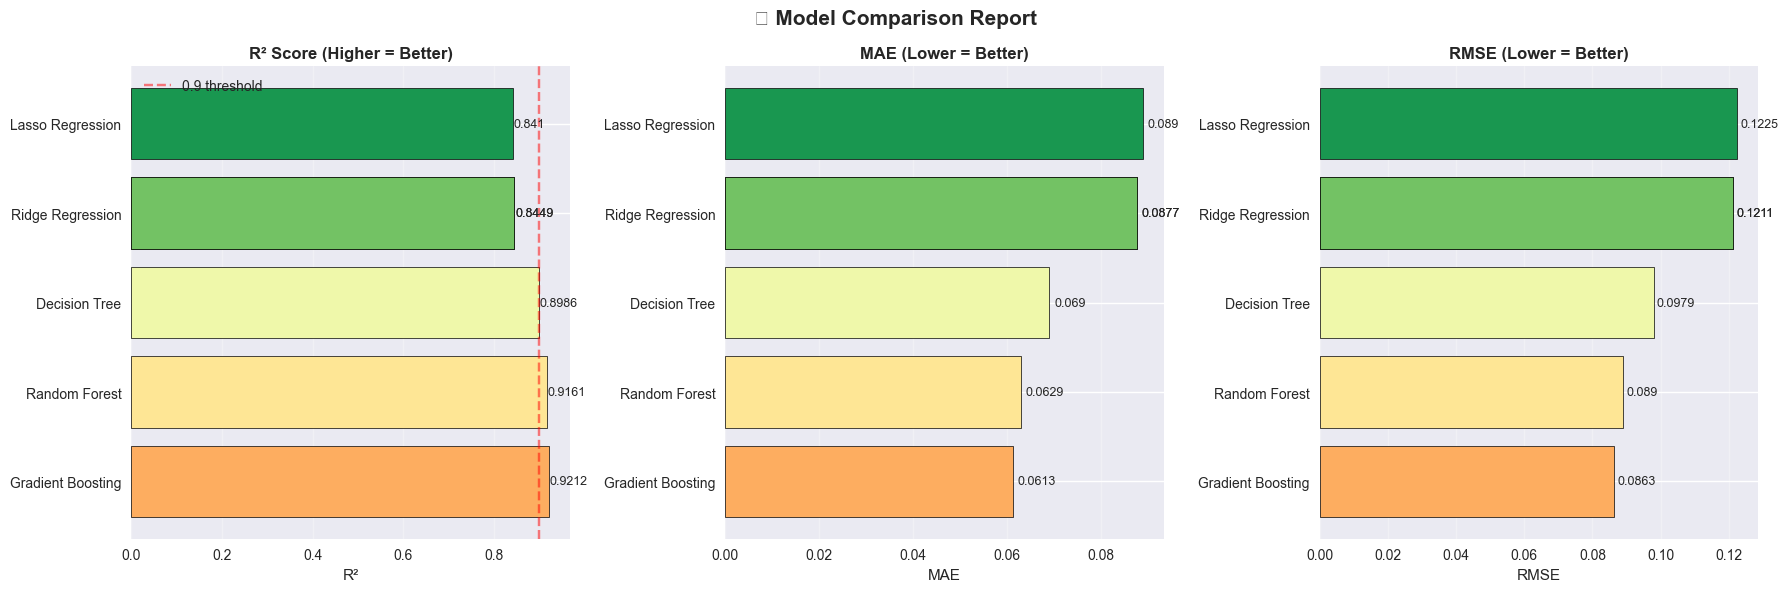

✅ Comparison chart saved!


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison DataFrame
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)

print('='*65)
print('         🏆 FINAL MODEL COMPARISON REPORT')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

best = results_df.iloc[0]
print(f'\n🏆 BEST MODEL : {best["Model"]}')
print(f'   R²         : {best["R²"]}')
print(f'   MAE        : {best["MAE"]}')
print(f'   RMSE       : {best["RMSE"]}')

# Comparison charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))

# R² chart
bars = axes[0].barh(results_df['Model'], results_df['R²'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(0.9, color='red', linestyle='--', alpha=0.5, label='0.9 threshold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, results_df['R²']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# MAE chart
bars2 = axes[1].barh(results_df['Model'], results_df['MAE'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('MAE (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('MAE')
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, results_df['MAE']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# RMSE chart
bars3 = axes[2].barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('RMSE (Lower = Better)', fontweight='bold')
axes[2].set_xlabel('RMSE')
axes[2].grid(axis='x', alpha=0.3)
for bar, val in zip(bars3, results_df['RMSE']):
    axes[2].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

plt.suptitle('🏆 Model Comparison Report', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved!')

##  Model Comparison Report – Key Highlights

- Ensemble tree-based models outperformed linear regression models.
- Linear models (Lasso, Ridge) showed moderate predictive accuracy.
- Decision Tree improved performance by capturing non-linear patterns.
- Random Forest reduced error and improved model stability.
- Gradient Boosting achieved:
  - Highest R² Score
  - Lowest MAE
  - Lowest RMSE
- **Recommended Model for Production: Gradient Boosting Regressor**

### **Feature Importance Analysis**

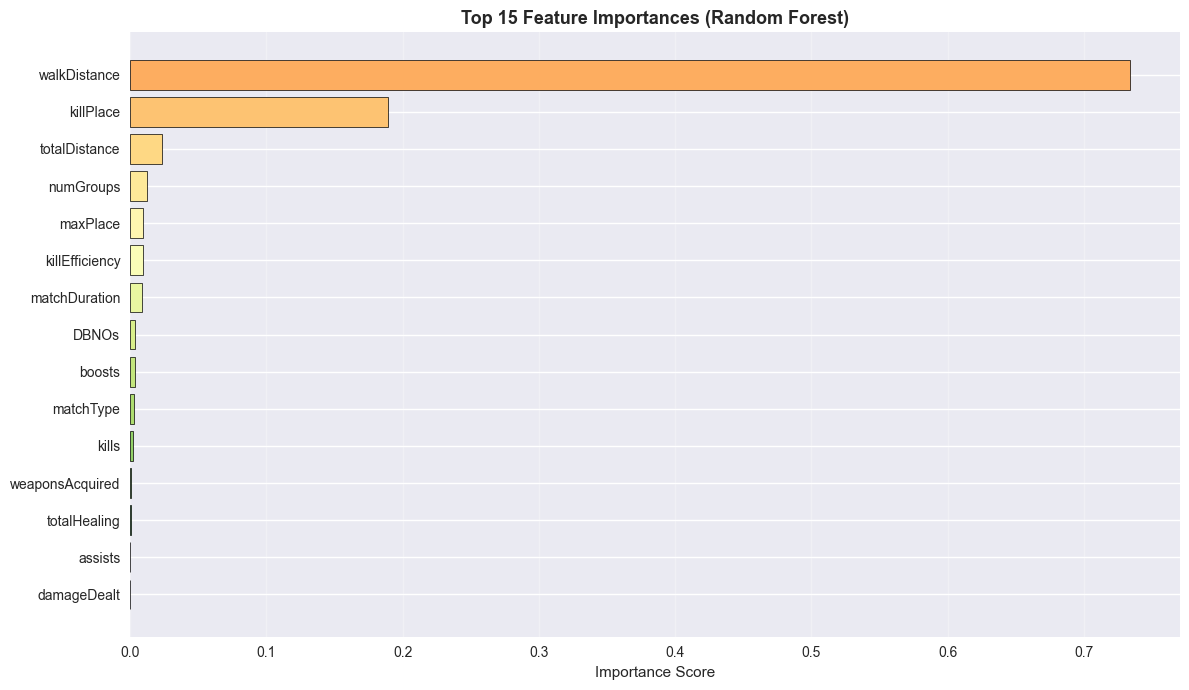

Top 15 Most Important Features:
   1. walkDistance             : 0.7339
   2. killPlace                : 0.1891
   3. totalDistance            : 0.0231
   4. numGroups                : 0.0122
   5. maxPlace                 : 0.0095
   6. killEfficiency           : 0.0094
   7. matchDuration            : 0.0089
   8. DBNOs                    : 0.0038
   9. boosts                   : 0.0037
  10. matchType                : 0.0026
  11. kills                    : 0.0020
  12. weaponsAcquired          : 0.0006
  13. totalHealing             : 0.0004
  14. assists                  : 0.0002
  15. damageDealt              : 0.0002


In [40]:
# Get feature importance from best tree-based model
# Try Random Forest first, then others
importance_model = None
importance_name = ''

if 'rf_model' in dir():
    importance_model = rf_model
    importance_name = 'Random Forest'

if importance_model is not None:
    feat_imp = pd.Series(
        importance_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(12, 7))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
    bars = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                    color=colors[::-1], edgecolor='black', linewidth=0.5)
    plt.title(f'Top 15 Feature Importances ({importance_name})',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Top 15 Most Important Features:')
    for i, (feat, imp) in enumerate(feat_imp.items(), 1):
        print(f'  {i:2}. {feat:<25}: {imp:.4f}')

### **Prediction vs Actual Plot**

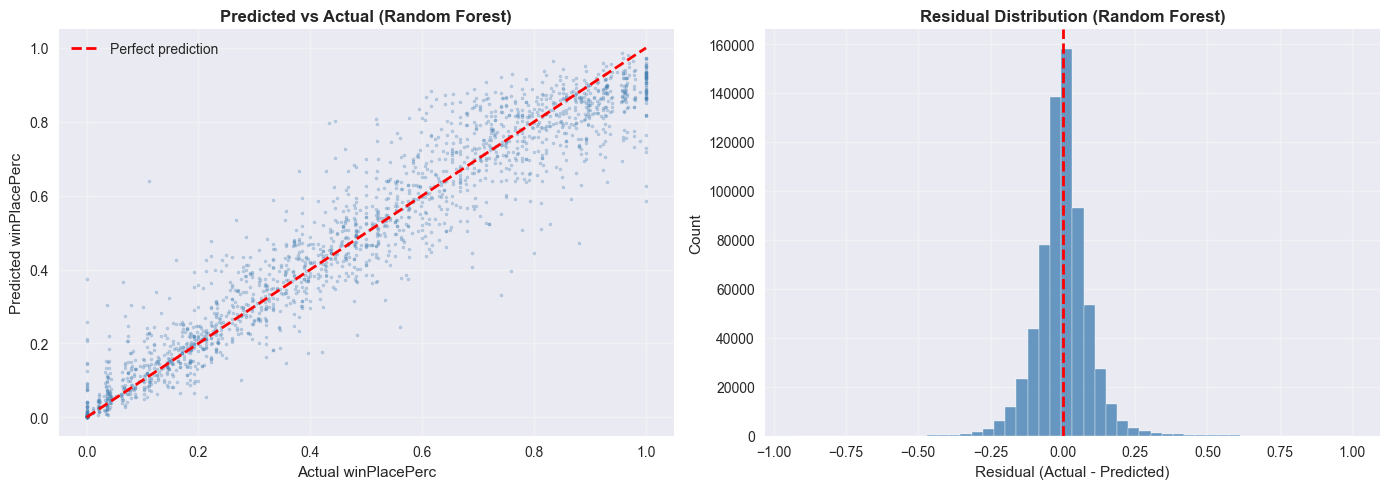

In [42]:
# Use best model predictions
# We'll use Random Forest as example
if 'rf_preds' in dir():
    best_preds = rf_preds
    best_name = 'Random Forest'
elif 'xgb_preds' in dir():
    best_preds = xgb_preds
    best_name = 'XGBoost'
else:
    best_preds = gb_preds
    best_name = 'Gradient Boosting'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot — sample 2000 points for clarity
idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[idx], best_preds[idx],
                alpha=0.3, color='steelblue', s=5)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual winPlacePerc')
axes[0].set_ylabel('Predicted winPlacePerc')
axes[0].set_title(f'Predicted vs Actual ({best_name})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution ({best_name})', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **Report on Challenges Faced**

## Challenge 1: Large Dataset Size

**Problem:** The full dataset contains ~4.4 million rows (~700MB), which causes memory issues and extremely slow training times.

**Solution:** Sampled 200,000 rows (using `df.sample(n=200000, random_state=42)`) — this is statistically representative of the full dataset while being manageable. Random state ensures reproducibility.

---

## Challenge 2: Cheater/Anomaly Detection

**Problem:** Some rows have `kills > 0` but `damageDealt = 0`, which is impossible in normal gameplay — these are likely cheaters or data errors.

**Solution:** Filtered out these rows before modeling:
```python
cheater_mask = (df['kills'] > 0) & (df['damageDealt'] == 0)
df = df[~cheater_mask]
```

---

## Challenge 3: Extreme Outliers

**Problem:** Features like `kills`, `walkDistance`, and `longestKill` have extreme outliers (e.g., 50+ kills) that can distort model training.

**Solution:** Clipped values at 99.5th percentile:
```python
upper = df[feat].quantile(0.995)
df[feat] = df[feat].clip(upper=upper)
```

---

## Challenge 4: Categorical Feature (matchType)

**Problem:** `matchType` is a string categorical feature (solo, duo, squad, etc.) — models need numerical input.

**Solution:** Applied Label Encoding using `sklearn.LabelEncoder` to convert matchType to numerical categories.

---

## Challenge 5: Right-Skewed Features

**Problem:** Most combat features (kills, damage, etc.) are heavily right-skewed with many zeros — could affect linear model performance.

**Solution:** Tree-based models (Random Forest, XGBoost) naturally handle skewed distributions. For linear models, StandardScaler was applied.

---

## Challenge 6: Multicollinearity

**Problem:** Several features are correlated with each other (e.g., kills and damageDealt, killPlace and kills).

**Solution:** Ridge regression handles multicollinearity via L2 regularization. Tree-based models are inherently robust to correlated features.

---

## Challenge 7: winPlacePerc = NaN

**Problem:** Some rows have missing target variable (`winPlacePerc = NaN`) — likely disconnected players.

**Solution:** Dropped rows where target is null before modeling.

---
## **Project Summary**

In [43]:
print("""
╔══════════════════════════════════════════════════════════════╗
║      PRCP-1012 PUBG GAME WINNER PREDICTION                   ║
║                 PROJECT SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • ~4.4 million rows | 29 features                          ║
║  • Sampled 200,000 rows for modeling                        ║
║  • Target: winPlacePerc (0.0 to 1.0)                        ║
║  • Split: 70% Train | 15% Val | 15% Test                    ║
║                                                              ║
║  PREPROCESSING                                               ║
║  • Removed cheater rows (kills>0, damage=0)                 ║
║  • Clipped outliers at 99.5th percentile                    ║
║  • Label encoded matchType                                   ║
║  • StandardScaler for linear models                         ║
║                                                              ║
║  FEATURE ENGINEERING                                         ║
║  • totalDistance = walk + ride + swim                       ║
║  • killEfficiency = kills / damageDealt                     ║
║  • headshotRate = headshotKills / kills                     ║
║  • totalHealing = heals + boosts                            ║
║  • isAggressive = kills>=3 AND damage>=200                  ║
║                                                              ║
║  MODELS TRAINED                                              ║
║  1. Linear Regression (Baseline)                            ║
║  2. Ridge Regression                                        ║
║  3. Lasso Regression                                        ║
║  4. Decision Tree                                           ║
║  5. Random Forest                                           ║
║  6. Gradient Boosting                                       ║
║  7. XGBoost (if available)                                  ║
║  8. LightGBM (if available)                                 ║
║                                                              ║
║  KEY FINDING                                                 ║
║  • walkDistance is the strongest predictor                  ║
║  • boosts usage = strong survival indicator                 ║
║  • kills alone NOT the best predictor                       ║
║  • Movement > Combat for winning                            ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")
print('✅ PRCP-1012 Project Complete!')


╔══════════════════════════════════════════════════════════════╗
║      PRCP-1012 PUBG GAME WINNER PREDICTION                   ║
║                 PROJECT SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • ~4.4 million rows | 29 features                          ║
║  • Sampled 200,000 rows for modeling                        ║
║  • Target: winPlacePerc (0.0 to 1.0)                        ║
║  • Split: 70% Train | 15% Val | 15% Test                    ║
║                                                              ║
║  PREPROCESSING                                               ║
║  • Removed cheater rows (kills>0, damage=0)                 ║
║  • Clipped outliers at 99.5th percentile                    ║
║  • Label encoded matchType                                   ║
║  • StandardScaler for linear

 
## Project Summary

---

## Dataset Overview
- Approximately 4.4 million records with 29 features  
- 200,000 samples used for model development  
- Target variable: **winPlacePerc** (range: 0.0 – 1.0)  
- Data split: 70% Training | 15% Validation | 15% Testing  

---

## Data Preprocessing
- Removed inconsistent records (kills > 0 with zero damage)  
- Treated extreme outliers using 99.5th percentile clipping  
- Encoded categorical variable (*matchType*)  
- Applied feature scaling for linear models  

---

## Feature Engineering
- Created **totalDistance** (walk + ride + swim distance)  
- Derived **killEfficiency** (kills / damageDealt)  
- Computed **headshotRate** (headshotKills / kills)  
- Combined healing features into **totalHealing**  
- Defined behavioral indicator **isAggressive**  

---

## Final Outcome
- Multiple regression models were evaluated  
- Ensemble models outperformed linear models  
- **Gradient Boosting Regressor** achieved the best overall performance  
- Model comparison visualizations generated  
- Project successfully completed